# Comparing Test Accuracy: Fine-tuning vs Without Fine-Tuning

**utils:**

In [45]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from plots_utils.quanti import refine_results, plot_mean_seeds_var_over_training, plot_final_best_test_acc, plot_final_best_worst_test_acc
import numpy as np
import os
from matplotlib import pyplot as plt
folder='figures/lr_exp/quanti_analysis/ft_analysis'
keyword = 'ft_analysis'
import pandas as pd

**utils for correlation evaluation:**

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
# from utils import *
import numpy as np
import pandas as pd
# from markov_models.experiments import exp1
from mpl_toolkits.axes_grid1 import make_axes_locatable
from  matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import os

main_folder = 'availability_matrices'

from sklearn.metrics import matthews_corrcoef

def phi_corr(seq1, seq2=[], lag=1):
    """
    Computes the phi association for two binary sequences.
    """
    if len(seq2) == 0:
        return matthews_corrcoef(seq1[:-lag], seq1[lag:])
    else:
        return matthews_corrcoef(seq1, seq2)
    
def av_mat_phi(availability_matrix):
    """
    Returns the list of ...
    """
    countries = availability_matrix.index

    t_corr_list = np.zeros(len(countries))
    for i, country in enumerate(countries):
        seq = availability_matrix.loc[country, :].values
        t_corr_list[i] = phi_corr(seq)
    t_corr_mean = np.mean(t_corr_list)

    sp_corr_dict = {"gp1":[], "gp2":[], "gp3":[]}
    for idxa, country_a in enumerate(countries): 
        for idxb, country_b in enumerate(countries):
            seq_a = availability_matrix.loc[country_a, :].values
            seq_b = availability_matrix.loc[country_b, :].values
            if idxa < 3 and idxb < 3 and idxa != idxb:
                print('group 1: ', idxa, idxb)
                sp_corr_dict['gp1'].append(phi_corr(seq_a, seq_b))
            elif (3 <= idxa < 5) and (3 <= idxb < 5) and idxa != idxb:
                print('group 2: ', idxa, idxb)
                sp_corr_dict['gp2'].append(phi_corr(seq_a, seq_b))
            elif (5 <= idxa < 7) and (5 <= idxb < 7) and idxa != idxb:
                print('group 3: ', idxa, idxb)
                sp_corr_dict['gp3'].append(phi_corr(seq_a, seq_b))
    sp_corr_list = []
    for value in sp_corr_dict.values():
        sp_corr_list.append(np.mean(value))
    sp_corr_mean = np.mean(sp_corr_list)
    return t_corr_list, t_corr_mean, sp_corr_dict, sp_corr_mean

# def av_mat_phi(availability_matrix):
#     """
#     Returns the list of ...
#     """
#     countries = availability_matrix.index

#     t_corr_list = np.zeros(len(countries))
#     for i, country in enumerate(countries):
#         seq = availability_matrix.loc[country, :].values
#         t_corr_list[i] = phi_corr(seq)
#     t_corr_mean = np.mean(t_corr_list)

#     sp_corr_list = []
#     for idxa, country_a in enumerate(countries): 
#         for idxb, country_b in enumerate(countries):
#             seq_a = availability_matrix.loc[country_a, :].values
#             seq_b = availability_matrix.loc[country_b, :].values
#             if idxa != idxb:
#                 sp_corr_list.append(phi_corr(seq_a, seq_b))
#     sp_corr_mean = np.mean(sp_corr_list)
#     return t_corr_list, t_corr_mean, {}, sp_corr_mean

def correlation_analysis(av_mat_name, folder, folder_out, df):
    """
    ...
    """

    newpath = "./av_mat_corr/"+folder_out+"/"+ av_mat_name
    if not os.path.exists(newpath):
        os.makedirs(newpath)

    client_labels = ['client 1', 'client 2', 'client 3', 'client 4', 'client 5', 'client 6', 'client 7']

    time_corr_df = pd.DataFrame(columns=['metric']+client_labels+['order'])

    # x --- load availability matrix --- x #
    av_mat_path = os.path.join('..', folder, 'av-mat_'+av_mat_name+".csv")
    availability_matrix = pd.DataFrame(pd.read_csv(av_mat_path, index_col=[0]))
    availability_matrix = availability_matrix.set_axis([i for i in range(100)], axis=1)
    availability_matrix = availability_matrix.set_axis([i+1 for i in range(7)], axis=0) # NEW!

    # # x --- plot availability matrix --- x #
    # plt.figure(figsize=(7, 2))
    # ax = plt.subplot()
    # cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256) 
    # sns.heatmap(availability_matrix.astype(int), annot=False, fmt='d', cbar=False, cmap=cmap, linewidths=0.5, linecolor='white', ax=ax) # create heatmap
    # xticks = ax.get_xticks()
    # xticks = xticks[::2]
    # ax.set_xticks(xticks) # set new xticks
    # plt.title(av_mat_name)
    # file_name = newpath+'/'+av_mat_name+'.png'
    # plt.show()

    # x --- phi association --- x #
    t_corr_list, t_corr_mean, sp_corr_dict, sp_corr_mean = av_mat_phi(availability_matrix)
    # print('Phi association:')
    # print('Time mean: ',np.round(t_corr_mean, 2))
    # print('Spatial mean: ',np.round(sp_corr_mean, 2))
    # print('x --------------- x')
    corr_order = str(np.argsort(t_corr_list) + 1)
    time_corr_df.loc[len(time_corr_df.index)] = ['phi'] + list(t_corr_list)+[corr_order]

    # Add a new row
    df.loc[len(df.index)] = [av_mat_name, t_corr_mean, sp_corr_mean]

    return(df)

## 35 percent participation

In [47]:
# main_folder = 'correlation_experiments_100rounds'
# config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="mnist_fig5/dataseed_12346", seeds=["78", "84"],
#                           algorithms=["fedavg"], events=["global"],
#                           lr_list=["5e-2", "1e-2", "1e-2"], alphas=["0.1"], n_clients_list=["7"],
#                           availabilities=[
# "gp100-35-tusu-10ft", 
# "gp100-35-tcsc-10ft", 
# "gp100-35-tcsu-10ft", 
# "gp100-12202835425057-tcsu-10ft", 
# "gp100-12202835425057-tusu-10ft", 
# "gp100-18183535355252-tcsu-10ft", 
# "gp100-18183535355252-tusu-10ft"
# ],
#                           n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

# raw_results_ft = load_experiment_results(config)
# raw_results_ft["availability"] = raw_results_ft["availability"].str.replace(r"-2$", "", regex=True)
# raw_results_ft['algorithm'] = "With fine-tuning"

# main_folder = 'correlation_experiments_100rounds'
# config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="mnist_fig5/dataseed_12346", seeds=["78", "84"],
#                           algorithms=["fedavg"], events=["global"],
#                           lr_list=["5e-2", "1e-2", "1e-2"], alphas=["0.1"], n_clients_list=["7"],
#                           availabilities=[
# "gp100-35-tusu", 
# "gp100-35-tcsc", 
# "gp100-35-tcsu", 
# "gp100-12202835425057-tcsu", 
# "gp100-12202835425057-tusu", 
# "gp100-18183535355252-tcsu", 
# "gp100-18183535355252-tusu"
# ],
#                           n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

## 50 percent participation

**load results**

In [48]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_fig5/dataseed_12345",
    seeds=["42", "78", "84"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2", "1e-2"],
    alphas=["0.1"],
    n_clients_list=["7"],
    availabilities=[
    "gp100-50-tusu-10ft", 
    "gp100-50-tcsc-3gps-10ft", 
    "gp100-50-tcsu-10ft", 
    "gp100-20304050607080-tcsu-10ft", 
    "gp100-20304050607080-tusu-10ft", 
    "gp100-25255050507575-tcsu-10ft", 
    "gp100-25255050507575-tusu-10ft"],
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
    batch_sizes=["128"]
)

raw_results_ft = load_experiment_results(config)
raw_results_ft["availability"] = raw_results_ft["availability"].str.replace(r"-2$", "", regex=True)
raw_results_ft['algorithm'] = "With fine-tuning"


config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_fig5/dataseed_12345",
    seeds=["42", "78", "84"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2", "1e-2"],
    alphas=["0.1"],
    n_clients_list=["7"],
    availabilities=[
    "gp100-50-tusu", 
    "gp100-50-tcsc-3gps", 
    "gp100-50-tcsu", 
    "gp100-20304050607080-tcsu", 
    "gp100-20304050607080-tusu", 
    "gp100-25255050507575-tcsu", 
    "gp100-25255050507575-tusu"],
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
    batch_sizes=["128"]
)

raw_results = load_experiment_results(config)
# raw_results["availability"] = raw_results["availability"].str.replace(r"-2$", "", regex=True)
raw_results['algorithm'] = "Without fine-tuning"

final_results = pd.concat([raw_results, raw_results_ft])


Processing experiments: 100%|██████████| 2/2 [00:02<00:00,  1.24s/it]


**get statistics**

In [49]:
res = final_results[["algorithm", "availability", "test_accuracy", "seed", "lr"]]

# only look at the final accuracy:
res.loc[:,['final_acc']] = res['test_accuracy'].apply(lambda x : x[-1])

# take the best value accross learning rates:
refined_res = res.groupby(['availability','algorithm', 'seed']).final_acc.apply(np.vstack).to_frame().reset_index()
refined_res['final_best_acc'] = refined_res['final_acc'].apply(lambda x : x.max())

refined_res = refined_res[['availability', 'final_best_acc', 'algorithm', 'seed']]

# regroup all seeds results:
refined_res = refined_res.groupby(['availability', 'algorithm']).final_best_acc.apply(np.vstack).to_frame().reset_index() # regroup seeds results

# compute the mean and std/3:
refined_res['mean_acc'] = refined_res['final_best_acc'].apply(lambda x : x.mean()*100)
refined_res['std_acc'] = refined_res['final_best_acc'].apply(lambda x : x.std()*100)

refined_res

,availability,algorithm,final_best_acc,mean_acc,std_acc
0,gp100-20304050607080-tcsu,Without fine-tuning,"[[0.9337999820709229], [0.9251999855041504], [...",92.796665,0.412660
1,gp100-20304050607080-tcsu-10ft,With fine-tuning,"[[0.9527000188827515], [0.9664000272750854], [...",96.600002,1.069984
2,gp100-20304050607080-tusu,Without fine-tuning,"[[0.9416999816894531], [0.9445000290870667], [...",94.630001,0.466763
3,gp100-20304050607080-tusu-10ft,With fine-tuning,"[[0.9785000085830688], [0.9800000190734863], [...",98.046668,0.182636
4,gp100-25255050507575-tcsu,Without fine-tuning,"[[0.9797999858856201], [0.9785000085830688], [...",97.946666,0.069441
5,gp100-25255050507575-tcsu-10ft,With fine-tuning,"[[0.9778000116348267], [0.9810000061988831], [...",98.030001,0.182391
6,gp100-25255050507575-tusu,Without fine-tuning,"[[0.9577999711036682], [0.9289000034332275], [...",94.989999,1.500022
7,gp100-25255050507575-tusu-10ft,With fine-tuning,"[[0.9805999994277954], [0.9810000061988831], [...",98.156667,0.109646
8,gp100-50-tcsc-3gps,Without fine-tuning,"[[0.9513999819755554], [0.9559000134468079], [...",95.186667,0.312019
9,gp100-50-tcsc-3gps-10ft,With fine-tuning,"[[0.9801999926567078], [0.9779999852180481], [...",97.959999,0.114310


**get correlation values**

In [50]:
df = pd.DataFrame(columns=["availability", "mean-tc", "mean-sc"])

av_mat_list = [
    "gp100-50-tusu-10ft", 
    "gp100-50-tcsc-3gps-10ft", 
    "gp100-50-tcsu-10ft", 
    "gp100-20304050607080-tcsu-10ft", 
    "gp100-20304050607080-tusu-10ft", 
    "gp100-25255050507575-tcsu-10ft", 
    "gp100-25255050507575-tusu-10ft",
    "gp100-50-tusu", 
    "gp100-50-tcsc-3gps", 
    "gp100-50-tcsu", 
    "gp100-20304050607080-tcsu", 
    "gp100-20304050607080-tusu", 
    "gp100-25255050507575-tcsu", 
    "gp100-25255050507575-tusu"]

# av_mat_list = ['uniform-CI-threshold', 'uniform-carbon-budget']
# av_mat_name = 'uniform-CI-threshold'
for av_mat_name in av_mat_list:
    correlation_analysis(av_mat_name, main_folder, "fig5", df)

group 1:  0 1
group 1:  0 2
group 1:  1 0
group 1:  1 2
group 1:  2 0
group 1:  2 1
group 2:  3 4
group 2:  4 3
group 3:  5 6
group 3:  6 5
group 1:  0 1
group 1:  0 2
group 1:  1 0
group 1:  1 2
group 1:  2 0
group 1:  2 1
group 2:  3 4
group 2:  4 3
group 3:  5 6
group 3:  6 5
group 1:  0 1
group 1:  0 2
group 1:  1 0
group 1:  1 2
group 1:  2 0
group 1:  2 1
group 2:  3 4
group 2:  4 3
group 3:  5 6
group 3:  6 5
group 1:  0 1
group 1:  0 2
group 1:  1 0
group 1:  1 2
group 1:  2 0
group 1:  2 1
group 2:  3 4
group 2:  4 3
group 3:  5 6
group 3:  6 5
group 1:  0 1
group 1:  0 2
group 1:  1 0
group 1:  1 2
group 1:  2 0
group 1:  2 1
group 2:  3 4
group 2:  4 3
group 3:  5 6
group 3:  6 5
group 1:  0 1
group 1:  0 2
group 1:  1 0
group 1:  1 2
group 1:  2 0
group 1:  2 1
group 2:  3 4
group 2:  4 3
group 3:  5 6
group 3:  6 5
group 1:  0 1
group 1:  0 2
group 1:  1 0
group 1:  1 2
group 1:  2 0
group 1:  2 1
group 2:  3 4
group 2:  4 3
group 3:  5 6
group 3:  6 5
group 1:  0 1
group 

**create latex table**

In [51]:
final = pd.merge(refined_res, df, on='availability', how='outer')

final = final[['availability', 'algorithm', 'mean_acc', 'std_acc', 'mean-tc', 'mean-sc']]

final = final.round(2)
final = final.applymap(lambda x: f"{x:.2f}" if isinstance(x, float) else x)


final_ft = final[final.algorithm=="With fine-tuning"][['availability', 'mean_acc', 'std_acc', 'mean-tc', 'mean-sc']]
final_noft = final[final.algorithm=="Without fine-tuning"][['availability', 'mean_acc', 'std_acc', 'mean-tc', 'mean-sc']]

# final_noft.reset_index(drop=True)

x_values = [a.replace('gp100-','').replace('-10ft', '-ft').replace('12202835425057', 'he1-35').replace('18183535355252', 'he2-35').replace('20304050607080', 'h1-50').replace('25255050507575', 'h2-50').replace('-3gps', '').replace('50-', '') for a in final_noft['availability'].values]
x_values

final_noft_T = final_noft.transpose()
final_noft_T.columns = final_noft_T.iloc[0]
final_noft_T = final_noft_T[1:]
final_noft.columns.values
final_noft_T.rename(columns=dict(zip(final_noft_T.columns.values, x_values)), inplace=True)
latex_table = final_noft_T.to_latex().replace('availability', 'No fine-tuning') + '\n\n'


# x_values = [a.replace('gp100-','').replace('-10ft', '-ft').replace('12202835425057', 'he1-35').replace('18183535355252', 'he2-35').replace('20304050607080', 'h1-50').replace('25255050507575', 'h2-50').replace('-3gps', '').replace('50-', '') for a in final_ft['availability'].values]

final_ft_T = final_ft.transpose()

final_ft_T.columns = final_ft_T.iloc[0]
final_ft_T = final_ft_T[1:]
final_ft.columns.values

final_ft_T.rename(columns=dict(zip(final_ft_T.columns.values, x_values)), inplace=True)
latex_table += final_ft_T.to_latex().replace('availability', 'Fine-tuning')

latex_table = latex_table.replace("mean_acc", "final accuracy").replace("std_acc", "std").replace("mean-tc", "time corr.").replace("mean-sc", "spatial corr.")

latex_table = latex_table.replace("\n\\bottomrule\n\\end{tabular}\n\n\n\\begin{tabular}{llllllll}\n\\toprule\nFine-tuning & h1-tcsu & h1-tusu & h2-tcsu & h2-tusu & tcsc & tcsu & tusu \\\\", '\n\\midrule\nWith Fine-tuning')
print(latex_table)

\begin{tabular}{llllllll}
\toprule
No fine-tuning & h1-tcsu & h1-tusu & h2-tcsu & h2-tusu & tcsc & tcsu & tusu \\
\midrule
final accuracy & 92.80 & 94.63 & 97.95 & 94.99 & 95.19 & 96.10 & 96.89 \\
std & 0.41 & 0.47 & 0.07 & 1.50 & 0.31 & 0.18 & 0.15 \\
time corr. & 0.71 & -0.01 & 0.74 & 0.01 & 0.77 & 0.71 & -0.01 \\
spatial corr. & -0.06 & 0.06 & 0.12 & -0.02 & 0.32 & 0.09 & 0.03 \\
\midrule
With Fine-tuning
\midrule
final accuracy & 96.60 & 98.05 & 98.03 & 98.16 & 97.96 & 97.96 & 98.06 \\
std & 1.07 & 0.18 & 0.18 & 0.11 & 0.11 & 0.09 & 0.12 \\
time corr. & 0.74 & 0.16 & 0.73 & 0.12 & 0.83 & 0.73 & 0.06 \\
spatial corr. & 0.09 & 0.12 & 0.08 & 0.13 & 0.46 & 0.09 & 0.06 \\
\bottomrule
\end{tabular}



C:\Users\c.q.rodriguez\AppData\Local\Temp\ipykernel_14620\2445429365.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  final = final.applymap(lambda x: f"{x:.2f}" if isinstance(x, float) else x)


**create model quality graph (no correlation values)**

Text(0, 0.5, 'Test Accuracy')

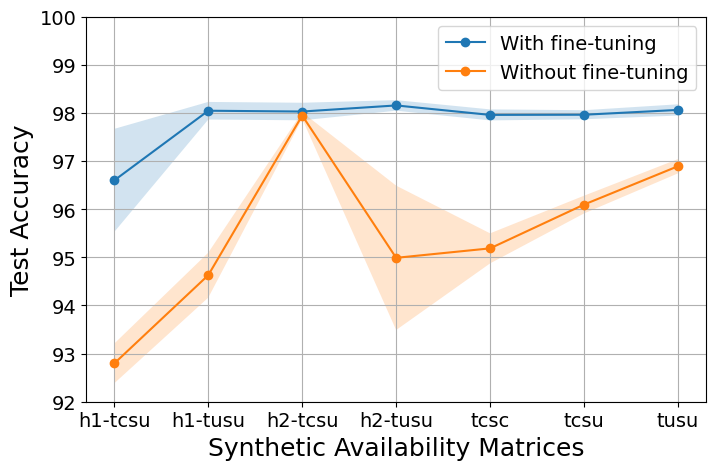

In [52]:
x_values = [a.replace('gp100-','').replace('-10ft', '').replace('12202835425057', 'he1-35').replace('18183535355252', 'he2-35').replace('20304050607080', 'h1-50').replace('25255050507575', 'h2-50').replace('-3gps', '').replace('50-', '') for a in refined_res[refined_res.algorithm=='With fine-tuning']['availability']]
plt.figure(figsize=(8,5))
ax=plt.gca()
for algo in ['With fine-tuning', 'Without fine-tuning']:

    y = refined_res[refined_res.algorithm==algo]['mean_acc']
    y_upper = (refined_res[refined_res.algorithm==algo]['mean_acc'] + refined_res[refined_res.algorithm==algo]['std_acc'])
    y_lower = (refined_res[refined_res.algorithm==algo]['mean_acc'] - refined_res[refined_res.algorithm==algo]['std_acc'])
    plt.plot(x_values, y, '-o', label=algo)
    ax.fill_between(x_values, y_upper, y_lower, alpha=0.2)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
# plt.title('Final best test accuracy (mean over seeds)')
plt.grid()
ax.set_ylim([92, 100])
plt.xlabel("Synthetic Availability Matrices", fontsize=18)
plt.ylabel("Test Accuracy", fontsize=18)
# plt.savefig(folder+'/ft_vs_noft.png', bbox_inches='tight')

## Av mat display

In [53]:
# av_mat_list = ['gp-35-tcsu-10ft',
#  'gp-50-tcsu-10ft',
# #  'gp-35-tusu-10ft',
#  'gaussian-uncorr-ft-35',
#  'gp-50-tusu-10ft',
#  'gp-35-tcsc-10ft-2',
#  'gp-35-tusc-10ft-2',
#  'gp-50-tcsc-10ft-2',
#  'gp-50-tusc-10ft-2',
#  'gp-20304050607080-tcsu-10ft',
#  'gp-20304050607080-tusu-10ft',
#  'gp-25255050507575-tcsu-10ft',
#  'gp-25255050507575-tusu-10ft',
#  'gp-35-tcsu',
#  'gp-50-tcsu',
#  'gp-35-tusu',
#  'gp-50-tusu',
#  'gp-35-tcsc-2',
#  'gp-35-tusc-2',
#  'gp-50-tcsc-2',
#  'gp-50-tusc-2',
#  'gp-20304050607080-tcsu',
#  'gp-20304050607080-tusu',
#  'gp-25255050507575-tcsu',
#  'gp-25255050507575-tusu']
# folder='lr_exp/av_mat'
# for av_mat_name in av_mat_list:
#     plot_av_mat(av_mat_name, folder)

## Markov Model

In [54]:
import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------------------------------------------------
# 1. 2-state Markov chain per client  →  λ₂
# ----------------------------------------------------------------------
def lambda2_two_state(seq: np.ndarray) -> float:
    """Return λ₂ of the empirical 2×2 transition matrix of a 0/1 sequence."""
    n00 = np.sum((seq[:-1] == 0) & (seq[1:] == 0))
    n01 = np.sum((seq[:-1] == 0) & (seq[1:] == 1))
    n10 = np.sum((seq[:-1] == 1) & (seq[1:] == 0))
    n11 = np.sum((seq[:-1] == 1) & (seq[1:] == 1))

    # Row-normalised transition probabilities with add-ε to avoid 0/0.
    eps = 1e-12
    p00 = n00 / (n00 + n01 + eps)
    p11 = n11 / (n10 + n11 + eps)

    # Second eigenvalue of a 2×2 stochastic matrix is p00 + p11 – 1
    return p00 + p11 - 1.0


def rho_TC(av_mat: np.ndarray) -> tuple[float, np.ndarray]:
    """Mean |λ₂| over all clients + per-client list."""
    lambdas = np.array([lambda2_two_state(av_mat[c]) for c in range(av_mat.shape[0])])
    return float(np.mean(np.abs(lambdas))), lambdas


# ----------------------------------------------------------------------
# 2. Joint 2ᴷ-state chain  →  single λ₂
# ----------------------------------------------------------------------
# def rho_TCSC(av_mat: np.ndarray) -> float:
#     """λ₂ of the joint chain (K clients ⇒ 2ᴷ states)."""
#     C, T = av_mat.shape
#     n_states = 1 << C                            # 2**C
#     counts = np.zeros((n_states, n_states), dtype=np.int64)

#     # Fast int-encoding of each column: bitstring → integer
#     powers = 1 << np.arange(C)                  # 2⁰,2¹,… for dot-product
#     state_ids = (av_mat.astype(int).T @ powers).astype(np.int64)  # shape (T,)

#     # Count transitions
#     for s, s_next in zip(state_ids[:-1], state_ids[1:]):
#         counts[s, s_next] += 1

#     # Row-stochastic transition matrix P
#     row_sum = counts.sum(axis=1, keepdims=True)
#     with np.errstate(divide="ignore", invalid="ignore"):
#         P = counts / row_sum
#         P[np.isnan(P)] = 0.0                    # rows that never appear

#     # Eigenvalues (128×128 is tiny → dense eig is fine)
#     eigvals = np.linalg.eigvals(P)
#     eigvals = np.sort(np.abs(eigvals))[::-1]    # descending by |λ|
#     return float(eigvals[1] if len(eigvals) > 1 else 0.0)
    
def rho_TCSC(av_mat: np.ndarray, alpha: float = 0.05) -> float:
    """
    λ₂ of the joint chain after Dirichlet(α) smoothing.
    alpha = 1  →  add-one / Laplace smoothing (recommended).
    """
    C, T = av_mat.shape
    n_states  = 1 << C
    counts    = np.zeros((n_states, n_states), dtype=np.int64)
    powers    = 1 << np.arange(C)
    state_ids = (av_mat.astype(int).T @ powers).astype(np.int64)

    # count transitions
    for s, s_next in zip(state_ids[:-1], state_ids[1:]):
        counts[s, s_next] += 1

    counts = counts + alpha                    # ← *** smoothing ***
    P      = counts / counts.sum(axis=1, keepdims=True)

    eigvals = np.linalg.eigvals(P)
    eigvals = np.sort(np.abs(eigvals))[::-1]   # |λ₀| ≥ |λ₁| ≥ …
    return float(eigvals[1])


# ----------------------------------------------------------------------
# 3. Plug into your correlation_analysis() skeleton
# ----------------------------------------------------------------------
def correlation_analysis(av_mat_name: str, folder: str, folder_out: str, df: pd.DataFrame):
    """Compute λ₂-based correlations and append to df."""
    # ---------- I/O ----------
    av_mat_path = Path("..") / folder / f"av-mat_{av_mat_name}.csv"
    av = pd.read_csv(av_mat_path, index_col=0).to_numpy(dtype=int)   # shape (K,T)

    # ---------- Markov metrics ----------
    mean_tc, tc_list = rho_TC(av)
    tcsc = rho_TCSC(av)                                              # single number

    # ---------- push to dataframe ----------
    df.loc[len(df)] = [av_mat_name, mean_tc, tcsc]
    return df

df = pd.DataFrame(columns=["availability", "mean-tc", "mean-sc"])

av_mat_list = [
    "gp100-50-tusu-10ft", 
    "gp100-50-tcsc-3gps-10ft", 
    "gp100-50-tcsu-10ft", 
    "gp100-20304050607080-tcsu-10ft", 
    "gp100-20304050607080-tusu-10ft", 
    "gp100-25255050507575-tcsu-10ft", 
    "gp100-25255050507575-tusu-10ft",
    "gp100-50-tusu", 
    "gp100-50-tcsc-3gps", 
    "gp100-50-tcsu", 
    "gp100-20304050607080-tcsu", 
    "gp100-20304050607080-tusu", 
    "gp100-25255050507575-tcsu", 
    "gp100-25255050507575-tusu"
]

# av_mat_list = ['uniform-CI-threshold', 'uniform-carbon-budget']
# av_mat_name = 'uniform-CI-threshold'
dfs = []
for av_mat_name in av_mat_list:
    dfs.append(correlation_analysis(av_mat_name, main_folder, "fig5", df))

In [55]:
dfs[0]

,availability,mean-tc,mean-sc
0,gp100-50-tusu-10ft,0.102507,0.579578
1,gp100-50-tcsc-3gps-10ft,0.829854,0.579129
2,gp100-50-tcsu-10ft,0.725948,0.579360
3,gp100-20304050607080-tcsu-10ft,0.744333,0.580378
4,gp100-20304050607080-tusu-10ft,0.160357,0.579443
5,gp100-25255050507575-tcsu-10ft,0.727573,0.579584
6,gp100-25255050507575-tusu-10ft,0.151261,0.579590
7,gp100-50-tusu,0.082274,0.157873
8,gp100-50-tcsc-3gps,0.766297,0.480430
9,gp100-50-tcsu,0.711487,0.343655
